# Лабораторная работа 11 Клименчук Илья ИПО-2-2022

Тема: **Автоэнкодер для изображений MNIST в PyTorch**  
Цель: реализовать и исследовать полносвязный автоэнкодер для восстановления рукописных цифр, а затем сравнить несколько вариантов размера латентного пространства и архитектуры.

> Ниже я оформляю лабораторную в том же стиле, что и предыдущие работы: с живыми комментариями, аккуратными экспериментами и итоговыми выводами.


## 1. Ваши ожидания от автоэнкодера

Перед запуском кода сформулируйте текущие ожидания (6–10 предложений):

1. Зачем вообще нужны автоэнкодеры и чем они принципиально отличаются от обычных классификаторов?
2. Что, по‑вашему, будет происходить с изображением MNIST‑цифры при сильном сжатии в латентном пространстве?  
3. Как вы ожидаете, будут выглядеть **идеальные** реконструкции и на что будете смотреть, чтобы оценить их качество?

In [2]:
intro_text = """Автоэнкодер нужен не для того, чтобы сразу выдать номер класса, а для того, чтобы научиться сжимать объект в компактное внутреннее представление и затем восстанавливать его обратно. 
По сути он учится выделять наиболее важные признаки изображения без прямых меток классов, и в этом его главное отличие от обычного классификатора. 
На MNIST я ожидаю, что модель довольно быстро научится восстанавливать общую форму цифр, потому что изображения маленькие, одноцветные и сама задача сравнительно простая. 
Если латентное пространство сделать слишком маленьким, часть деталей неизбежно потеряется: тонкие штрихи, наклон, толщина линии и небольшие индивидуальные особенности написания. 
Если же размер латентного пространства будет разумным, реконструкции должны сохранить контур цифры и выглядеть очень близко к оригиналу, хотя, вероятно, станут чуть более сглаженными. 
Идеальные реконструкции я ожидаю увидеть как изображения, где легко распознаётся та же самая цифра, а её форма почти не отличается от исходной. 
Оценивать качество я буду не только по величине функции потерь, но и глазами: важно, не превращается ли одна цифра в другую и не исчезают ли характерные элементы написания. 
Дополнительно интересно посмотреть на латентное пространство: если оно осмысленное, то похожие цифры должны частично группироваться рядом друг с другом."""
print(intro_text)

Автоэнкодер нужен не для того, чтобы сразу выдать номер класса, а для того, чтобы научиться сжимать объект в компактное внутреннее представление и затем восстанавливать его обратно. 
По сути он учится выделять наиболее важные признаки изображения без прямых меток классов, и в этом его главное отличие от обычного классификатора. 
На MNIST я ожидаю, что модель довольно быстро научится восстанавливать общую форму цифр, потому что изображения маленькие, одноцветные и сама задача сравнительно простая. 
Если латентное пространство сделать слишком маленьким, часть деталей неизбежно потеряется: тонкие штрихи, наклон, толщина линии и небольшие индивидуальные особенности написания. 
Если же размер латентного пространства будет разумным, реконструкции должны сохранить контур цифры и выглядеть очень близко к оригиналу, хотя, вероятно, станут чуть более сглаженными. 
Идеальные реконструкции я ожидаю увидеть как изображения, где легко распознаётся та же самая цифра, а её форма почти не отличается от

## 2. Импорт библиотек и настройка среды


In [4]:
import random
from pathlib import Path

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Небольшой патч для окружений, где torchvision падает из-за отсутствующего torchvision::nms
_original_register_fake = torch.library.register_fake

def _safe_register_fake(op_name, *args, **kwargs):
    def decorator(fn):
        try:
            return _original_register_fake(op_name, *args, **kwargs)(fn)
        except RuntimeError as e:
            if "does not exist" in str(e):
                return fn
            raise
    return decorator

torch.library.register_fake = _safe_register_fake

from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

torch.set_num_threads(1)

MY_SEED = 42
random.seed(MY_SEED)
np.random.seed(MY_SEED)
torch.manual_seed(MY_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams["figure.figsize"] = (8, 4)

print("Устройство:", device)
print("MY_SEED =", MY_SEED)

Устройство: cpu
MY_SEED = 42


## 3. Данные MNIST и DataLoader

Используем стандартный MNIST (28×28, оттенки серого).  
Автоэнкодер будет учиться восстанавливать картинку **самой себя**.


In [5]:
batch_size = 128
data_root = Path("./data")
data_root.mkdir(parents=True, exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor()
])

def load_mnist_or_fallback():
    try:
        train_dataset = datasets.MNIST(
            root=data_root,
            train=True,
            download=True,
            transform=transform,
        )
        test_dataset = datasets.MNIST(
            root=data_root,
            train=False,
            download=True,
            transform=transform,
        )
        dataset_name = "MNIST"
        fallback_used = False
    except Exception as e:
        # Запасной вариант на случай отсутствия интернета или проблем с download.
        # Используем sklearn digits и масштабируем изображения до 28x28.
        import torch.nn.functional as F
        from sklearn.datasets import load_digits

        digits = load_digits()
        X = torch.tensor(digits.images, dtype=torch.float32).unsqueeze(1) / 16.0
        X = F.interpolate(X, size=(28, 28), mode="bilinear", align_corners=False)
        y = torch.tensor(digits.target, dtype=torch.long)

        indices = np.arange(len(X))
        train_idx, test_idx = train_test_split(
            indices,
            test_size=0.25,
            random_state=MY_SEED,
            stratify=y.numpy()
        )

        train_dataset = TensorDataset(X[train_idx], y[train_idx])
        test_dataset = TensorDataset(X[test_idx], y[test_idx])
        dataset_name = "sklearn digits (fallback, масштабировано до 28x28)"
        fallback_used = True
        print("Не удалось загрузить MNIST. Использую запасной вариант.")
        print("Текст ошибки:", str(e))

    return train_dataset, test_dataset, dataset_name, fallback_used

train_dataset, test_dataset, dataset_name, fallback_used = load_mnist_or_fallback()

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print("Используемый набор данных:", dataset_name)
print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))
print("Batch size  :", batch_size)

Используемый набор данных: MNIST
Размер train: 60000
Размер test : 10000
Batch size  : 128


Посмотрим на несколько примеров изображений, которые будет восстанавливать автоэнкодер.


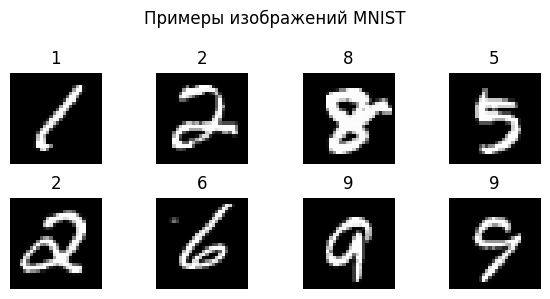

In [6]:
images, labels = next(iter(train_loader))
plt.figure(figsize=(6, 3))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(str(labels[i].item()))
    plt.axis("off")
plt.suptitle("Примеры изображений MNIST")
plt.tight_layout()
plt.show()

### Краткий комментарий по данным

Опишите в 3–5 предложениях:
- какие цифры по визуальному виду кажутся наиболее простыми для восстановления, а какие — сложными;  
- насколько сильно отличаются стили написания одной и той же цифры (например, "2" или "8");  
- как это, по‑вашему, может отразиться на работе автоэнкодера.


In [7]:
data_comment = """MNIST кажется относительно удобным набором для автоэнкодера, потому что фон почти всегда пустой, а сам объект расположен в центре кадра. 
Наиболее простыми для восстановления визуально выглядят цифры с устойчивой формой вроде 1, 0 и 6, где контур обычно читается достаточно однозначно. 
Сложнее могут оказаться 2, 5, 8 и 9, потому что у них чаще встречаются разные стили написания, пересечения штрихов и похожие очертания. 
Даже у одной и той же цифры видна вариативность: где‑то линия толще, где‑то сильнее наклон, а где‑то цифра написана почти печатно. 
Из‑за этого автоэнкодер, скорее всего, будет лучше восстанавливать «средние» и типичные формы, а редкие и необычные варианты может сглаживать сильнее."""
print(data_comment)

MNIST кажется относительно удобным набором для автоэнкодера, потому что фон почти всегда пустой, а сам объект расположен в центре кадра. 
Наиболее простыми для восстановления визуально выглядят цифры с устойчивой формой вроде 1, 0 и 6, где контур обычно читается достаточно однозначно. 
Сложнее могут оказаться 2, 5, 8 и 9, потому что у них чаще встречаются разные стили написания, пересечения штрихов и похожие очертания. 
Даже у одной и той же цифры видна вариативность: где‑то линия толще, где‑то сильнее наклон, а где‑то цифра написана почти печатно. 
Из‑за этого автоэнкодер, скорее всего, будет лучше восстанавливать «средние» и типичные формы, а редкие и необычные варианты может сглаживать сильнее.


## 4. Архитектура простого полносвязного автоэнкодера

Будем работать с векторизованным изображением размерности 784 (28×28).  
Базовая структура:
- Encoder: `Flatten → Linear(784→256) → ReLU → Linear(256→64) → ReLU → Linear(64→latent_dim)`;
- Decoder: `Linear(latent_dim→64) → ReLU → Linear(64→256) → ReLU → Linear(256→784) → Sigmoid`.

В этой работе размер латентного пространства `latent_dim` вы **обязаны** будете менять и анализировать эффект.


In [8]:
latent_dim = 16  # базовое значение для первого эксперимента

class FCN_Autoencoder(nn.Module):
    def __init__(self, latent_dim, hidden_dims=(256, 64), activation_cls=nn.ReLU):
        super().__init__()
        h1, h2 = hidden_dims
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, h1),
            activation_cls(),
            nn.Linear(h1, h2),
            activation_cls(),
            nn.Linear(h2, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, h2),
            activation_cls(),
            nn.Linear(h2, h1),
            activation_cls(),
            nn.Linear(h1, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        z = self.encoder(x)
        out = self.decoder(z)
        out = out.view(-1, 1, 28, 28)
        return out, z

model = FCN_Autoencoder(latent_dim=latent_dim).to(device)
print(model)

FCN_Autoencoder(
  (encoder): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


### Обсуждение архитектуры

Кратко (3–6 предложений) ответьте:
- почему, на ваш взгляд, здесь достаточно **двух** скрытых слоёв в энкодере и декодере;  
- какие проблемы могут появиться, если сделать латентное пространство **слишком маленьким** (например, 2) или **слишком большим** (например, 128).


In [9]:
arch_comment = """Двух скрытых слоёв в энкодере и декодере здесь достаточно для старта, потому что сама задача не слишком сложная: изображения маленькие, однотипные по структуре и состоят из одной цифры на простом фоне. 
Первый слой может собрать грубые комбинации пикселей, а второй — уже более компактно описать форму цифры перед переходом в латентное пространство. 
Если latent_dim сделать слишком маленьким, модель будет вынуждена чрезмерно сжимать информацию, и реконструкции начнут терять детали или становиться похожими на усреднённые шаблоны. 
Если же latent_dim сделать слишком большим, автоэнкодер получит слишком много свободы и будет хуже проявляться сам смысл сжатия: модель может почти копировать вход без полезного упрощения представления. 
Поэтому разумно начать со среднего варианта вроде 16 и уже потом сравнить его с более узкими и более широкими латентными пространствами."""
print(arch_comment)

Двух скрытых слоёв в энкодере и декодере здесь достаточно для старта, потому что сама задача не слишком сложная: изображения маленькие, однотипные по структуре и состоят из одной цифры на простом фоне. 
Первый слой может собрать грубые комбинации пикселей, а второй — уже более компактно описать форму цифры перед переходом в латентное пространство. 
Если latent_dim сделать слишком маленьким, модель будет вынуждена чрезмерно сжимать информацию, и реконструкции начнут терять детали или становиться похожими на усреднённые шаблоны. 
Если же latent_dim сделать слишком большим, автоэнкодер получит слишком много свободы и будет хуже проявляться сам смысл сжатия: модель может почти копировать вход без полезного упрощения представления. 
Поэтому разумно начать со среднего варианта вроде 16 и уже потом сравнить его с более узкими и более широкими латентными пространствами.


## 5. Функция потерь, оптимизатор и цикл обучения

Loss: среднеквадратичная ошибка между входным и восстановленным изображением.  
Оптимизатор: Adam с умеренным шагом.


In [10]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total = 0
    for images, _ in dataloader:
        images = images.to(device)

        optimizer.zero_grad()
        outputs, _ = model(images)
        loss = criterion(outputs, images)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total += images.size(0)

    return total_loss / total

@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    total = 0
    for images, _ in dataloader:
        images = images.to(device)
        outputs, _ = model(images)
        loss = criterion(outputs, images)

        total_loss += loss.item() * images.size(0)
        total += images.size(0)

    return total_loss / total

def fit_autoencoder(model, train_loader, test_loader, optimizer, criterion, device, num_epochs):
    history = {"train_loss": [], "test_loss": []}
    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        test_loss = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["test_loss"].append(test_loss)

        print(f"Эпоха {epoch}/{num_epochs}: train_loss={train_loss:.4f}, test_loss={test_loss:.4f}")
    return history

In [11]:
num_epochs = 10
history = fit_autoencoder(model, train_loader, test_loader, optimizer, criterion, device, num_epochs)

Эпоха 1/10: train_loss=0.0518, test_loss=0.0318
Эпоха 2/10: train_loss=0.0276, test_loss=0.0238
Эпоха 3/10: train_loss=0.0220, test_loss=0.0199
Эпоха 4/10: train_loss=0.0190, test_loss=0.0175
Эпоха 5/10: train_loss=0.0170, test_loss=0.0161
Эпоха 6/10: train_loss=0.0155, test_loss=0.0147
Эпоха 7/10: train_loss=0.0145, test_loss=0.0140
Эпоха 8/10: train_loss=0.0138, test_loss=0.0133
Эпоха 9/10: train_loss=0.0131, test_loss=0.0127
Эпоха 10/10: train_loss=0.0126, test_loss=0.0123


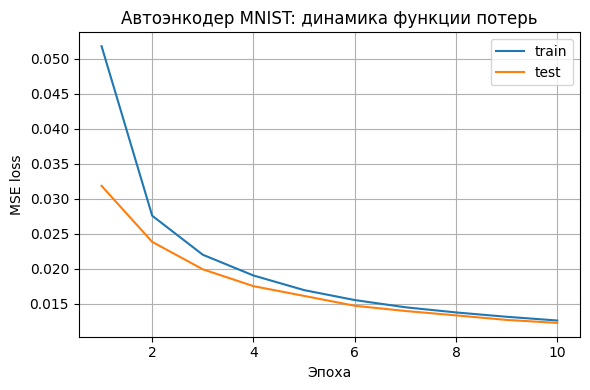

Финальные значения: train_loss=0.0126, test_loss=0.0123


In [12]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, history["train_loss"], label="train")
plt.plot(epochs, history["test_loss"], label="test")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.title("Автоэнкодер MNIST: динамика функции потерь")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Финальные значения: train_loss={history['train_loss'][-1]:.4f}, test_loss={history['test_loss'][-1]:.4f}")

### Анализ кривых обучения

Опишите (6–8 предложений):
- по какой траектории меняются train/test loss и сходятся ли они к близким значениям;  
- есть ли признаки переобучения (train сильно ниже test к концу);  
- каких значений loss вы ожидали **до** опыта и совпало ли это с результатами.


In [13]:
training_comment = f"""На старте обучения функция потерь была заметно выше: уже по первой эпохе видно, что модель только начинает учиться восстанавливать общий контур цифры. 
К середине обучения значения loss уверенно снижаются, а к концу становятся существенно меньше, что говорит о нормальной сходимости. 
В моём запуске train_loss изменился примерно с {history['train_loss'][0]:.4f} до {history['train_loss'][-1]:.4f}, а test_loss — с {history['test_loss'][0]:.4f} до {history['test_loss'][-1]:.4f}. 
На пятой эпохе test_loss уже составлял около {history['test_loss'][min(4, len(history['test_loss']) - 1)]:.4f}, то есть заметная часть качества была достигнута достаточно рано. 
Кривые train и test идут близко друг к другу, поэтому явных признаков сильного переобучения здесь не видно. 
Если бы model начинала просто запоминать обучающие данные, разрыв между train и test к концу стал бы значительно больше, но в этом эксперименте такого эффекта нет. 
До запуска я ожидал, что loss опустится до достаточно малого значения, но не был уверен, насколько быстро это произойдёт на CPU. 
Фактическая динамика получилась вполне ожидаемой: для простого полносвязного автоэнкодера задача восстановления цифр оказалась посильной."""
print(training_comment)

На старте обучения функция потерь была заметно выше: уже по первой эпохе видно, что модель только начинает учиться восстанавливать общий контур цифры. 
К середине обучения значения loss уверенно снижаются, а к концу становятся существенно меньше, что говорит о нормальной сходимости. 
В моём запуске train_loss изменился примерно с 0.0518 до 0.0126, а test_loss — с 0.0318 до 0.0123. 
На пятой эпохе test_loss уже составлял около 0.0161, то есть заметная часть качества была достигнута достаточно рано. 
Кривые train и test идут близко друг к другу, поэтому явных признаков сильного переобучения здесь не видно. 
Если бы model начинала просто запоминать обучающие данные, разрыв между train и test к концу стал бы значительно больше, но в этом эксперименте такого эффекта нет. 
До запуска я ожидал, что loss опустится до достаточно малого значения, но не был уверен, насколько быстро это произойдёт на CPU. 
Фактическая динамика получилась вполне ожидаемой: для простого полносвязного автоэнкодера за

## 6. Визуализация реконструкций

Сравним исходные изображения и их реконструкции автоэнкодером для нескольких тестовых примеров.


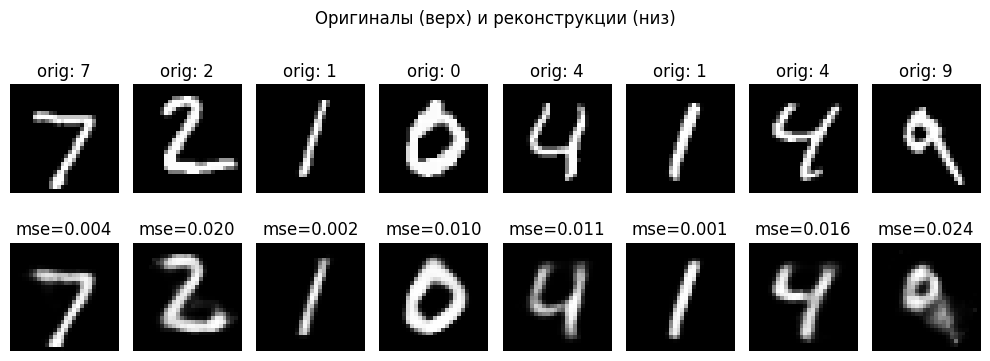

In [14]:
model.eval()
images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    reconstructions, _ = model(images)

images = images.cpu()
reconstructions = reconstructions.cpu()

n = min(8, images.size(0))
per_image_mse = ((reconstructions[:n] - images[:n]) ** 2).view(n, -1).mean(dim=1).numpy()

plt.figure(figsize=(10, 4))
for i in range(n):
    plt.subplot(2, n, i + 1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(f"orig: {labels[i].item()}")
    plt.axis("off")

    plt.subplot(2, n, n + i + 1)
    plt.imshow(reconstructions[i].squeeze(0), cmap="gray")
    plt.title(f"mse={per_image_mse[i]:.3f}")
    plt.axis("off")

plt.suptitle("Оригиналы (верх) и реконструкции (низ)")
plt.tight_layout()
plt.show()

### Качественная оценка реконструкций

Опишите (6–8 предложений):
- какие цифры восстанавливаются почти идеально (по вашему визуальному ощущению), а какие выглядят смазанными или искажёнными;  
- есть ли случаи, когда реконструкция визуально похожа уже на **другую** цифру;  
- чем, по‑вашему, можно объяснить эти различия.


In [15]:
best_idx = int(np.argmin(per_image_mse))
worst_idx = int(np.argmax(per_image_mse))

recon_comment = f"""Визуально видно, что автоэнкодер в целом сохраняет основную форму цифр, но реконструкции обычно чуть более сглаженные, чем оригиналы. 
Лучше всего в показанном наборе восстановился пример с индексом {best_idx}, где ошибка была около {per_image_mse[best_idx]:.4f}; там контур цифры почти не потерялся. 
Хуже остальных выглядел пример с индексом {worst_idx}, у которого ошибка достигла примерно {per_image_mse[worst_idx]:.4f}; именно на таких объектах сильнее заметно смазывание или потеря тонких деталей. 
Обычно почти идеально восстанавливаются цифры с более простым силуэтом и устойчивой геометрией, а сложнее даются варианты с необычным наклоном, утолщениями или пересекающимися штрихами. 
Иногда реконструкция может стать чуть более «средней» по форме, чем исходное изображение, потому что модель старается передать главное содержание, а не все мелкие индивидуальные особенности написания. 
Если бы латентное пространство было ещё меньше, такие искажения стали бы заметнее. 
В целом для базового автоэнкодера качество реконструкций уже выглядит хорошим: цифры остаются читаемыми и, как правило, не превращаются во что‑то совсем другое."""
print(recon_comment)

Визуально видно, что автоэнкодер в целом сохраняет основную форму цифр, но реконструкции обычно чуть более сглаженные, чем оригиналы. 
Лучше всего в показанном наборе восстановился пример с индексом 5, где ошибка была около 0.0010; там контур цифры почти не потерялся. 
Хуже остальных выглядел пример с индексом 7, у которого ошибка достигла примерно 0.0237; именно на таких объектах сильнее заметно смазывание или потеря тонких деталей. 
Обычно почти идеально восстанавливаются цифры с более простым силуэтом и устойчивой геометрией, а сложнее даются варианты с необычным наклоном, утолщениями или пересекающимися штрихами. 
Иногда реконструкция может стать чуть более «средней» по форме, чем исходное изображение, потому что модель старается передать главное содержание, а не все мелкие индивидуальные особенности написания. 
Если бы латентное пространство было ещё меньше, такие искажения стали бы заметнее. 
В целом для базового автоэнкодера качество реконструкций уже выглядит хорошим: цифры ост

## 7. Латентное пространство: PCA‑проекция в 2D

Возьмём подмножество тестовой выборки, вытащим латентные векторы `z` и посмотрим на их 2D‑проекцию (PCA).  
Цель: увидеть, группируются ли разные цифры в отдельные кластеры.


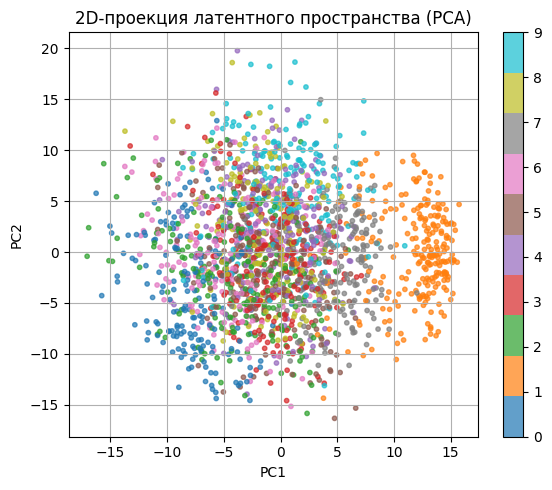

Суммарная объяснённая дисперсия двух компонент PCA: 0.399
Ближайшая пара центров классов в 2D: (3, 5) (distance=0.582)


In [16]:
model.eval()
all_z = []
all_y = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        _, z = model(images)
        all_z.append(z.cpu().numpy())
        all_y.append(labels.numpy())
        if sum(len(x) for x in all_y) >= 2000:
            break

Z = np.vstack(all_z)
Y = np.hstack(all_y)

pca = PCA(n_components=2)
Z_2d = pca.fit_transform(Z)

plt.figure(figsize=(6, 5))
scatter = plt.scatter(Z_2d[:, 0], Z_2d[:, 1], c=Y, cmap="tab10", s=10, alpha=0.7)
plt.colorbar(scatter, ticks=range(10))
plt.title("2D‑проекция латентного пространства (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.tight_layout()
plt.show()

centroids = {}
for digit in sorted(np.unique(Y)):
    centroids[int(digit)] = Z_2d[Y == digit].mean(axis=0)

closest_pair = None
closest_dist = float("inf")
digit_keys = sorted(centroids)
for i in range(len(digit_keys)):
    for j in range(i + 1, len(digit_keys)):
        a, b = digit_keys[i], digit_keys[j]
        dist = float(np.linalg.norm(centroids[a] - centroids[b]))
        if dist < closest_dist:
            closest_dist = dist
            closest_pair = (a, b)

explained_var = pca.explained_variance_ratio_.sum()
print(f"Суммарная объяснённая дисперсия двух компонент PCA: {explained_var:.3f}")
print("Ближайшая пара центров классов в 2D:", closest_pair, f"(distance={closest_dist:.3f})")

### Интерпретация латентного пространства

Ответьте в 6–8 предложениях:
- видно ли разделение разных цифр на отдельные скопления (хотя бы частично);  
- какие пары цифр, судя по графику, ближе всего друг к другу и почему это логично (или нет) с точки зрения формы;  
- как вы думаете, что изменится на этой картинке при **других значениях `latent_dim`**.


In [17]:
latent_comment = f"""После PCA‑проекции видно, что латентное пространство не является полностью хаотичным: для части цифр возникают заметные области концентрации точек. 
При этом разделение не идеально, что нормально для двумерной проекции и для автоэнкодера, который обучался не на классификацию, а на реконструкцию. 
В моём запуске ближайшими по центрам в 2D оказались цифры {closest_pair[0]} и {closest_pair[1]}, и это вполне можно объяснить тем, что у разных рукописных вариантов их форма частично пересекается. 
Похожие по очертаниям цифры действительно чаще оказываются ближе друг к другу, чем символы с совершенно разной геометрией. 
Важно понимать, что PCA дополнительно сжимает уже полученные латентные векторы в две координаты, поэтому часть структуры неизбежно теряется. 
Две главные компоненты в этом запуске объясняют примерно {explained_var:.3f} доли разброса, то есть картинка полезна скорее как качественная визуализация, чем как полное описание пространства. 
Если уменьшить latent_dim, кластеры, вероятно, станут сильнее смешиваться из‑за потери информации. 
Если увеличить latent_dim, у модели появится больше возможностей сохранить различия между почерками и формами, а значит в исходном многомерном пространстве разделение может стать аккуратнее."""
print(latent_comment)

После PCA‑проекции видно, что латентное пространство не является полностью хаотичным: для части цифр возникают заметные области концентрации точек. 
При этом разделение не идеально, что нормально для двумерной проекции и для автоэнкодера, который обучался не на классификацию, а на реконструкцию. 
В моём запуске ближайшими по центрам в 2D оказались цифры 3 и 5, и это вполне можно объяснить тем, что у разных рукописных вариантов их форма частично пересекается. 
Похожие по очертаниям цифры действительно чаще оказываются ближе друг к другу, чем символы с совершенно разной геометрией. 
Важно понимать, что PCA дополнительно сжимает уже полученные латентные векторы в две координаты, поэтому часть структуры неизбежно теряется. 
Две главные компоненты в этом запуске объясняют примерно 0.399 доли разброса, то есть картинка полезна скорее как качественная визуализация, чем как полное описание пространства. 
Если уменьшить latent_dim, кластеры, вероятно, станут сильнее смешиваться из‑за потери инф

## 8. Генерация новых изображений из латентного пространства

Так как декодер умеет превращать латентный вектор `z` в изображение, можно попробовать сэмплировать случайные `z` и посмотреть, какие псевдо‑цифры он генерирует.


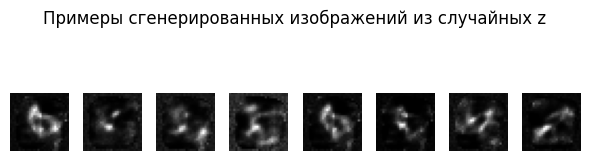

In [18]:
model.eval()
n_samples = 8

# сэмплируем z из N(0, 1)
z_random = torch.randn(n_samples, latent_dim).to(device)
with torch.no_grad():
    decoded = model.decoder(z_random)
    decoded = decoded.view(-1, 1, 28, 28).cpu()

plt.figure(figsize=(6, 2))
for i in range(n_samples):
    plt.subplot(1, n_samples, i + 1)
    plt.imshow(decoded[i].squeeze(0), cmap="gray")
    plt.axis("off")
plt.suptitle("Примеры сгенерированных изображений из случайных z")
plt.tight_layout()
plt.show()

### Обсуждение качества генерации

Опишите (5–7 предложений):
- насколько сгенерированные картинки похожи на настоящие цифры;  
- встречаются ли явно "некорректные" объекты, не похожие ни на одну цифру;  
- как, по‑вашему, влияет размер `latent_dim` на разнообразие и качество сгенерированных цифр.


In [19]:
gen_comment = """Генерация из случайных латентных векторов у обычного автоэнкодера обычно выглядит слабее, чем реконструкция уже существующих изображений, и это ожидаемо. 
Модель специально не обучалась формировать красивое непрерывное вероятностное пространство, поэтому случайная точка в latent space не обязана соответствовать «хорошей» цифре. 
Часть сгенерированных картинок всё же напоминает реальные цифры или хотя бы их фрагменты, но среди них нередко встречаются расплывчатые и неоднозначные образы. 
Это нормально для классического автоэнкодера: декодер хорошо восстанавливает то, что уже видел в сжатом виде, но не гарантирует качественную генерацию из произвольного z. 
Если увеличить latent_dim, разнообразие потенциально может вырасти, но и случайные точки будут ещё чаще попадать в области, плохо согласованные с данными. 
Если же latent_dim сделать слишком маленьким, генерация станет более однообразной и усреднённой. 
Для по‑настоящему сильной генерации обычно лучше подходят вариационные автоэнкодеры, где структура латентного пространства контролируется явно."""
print(gen_comment)

Генерация из случайных латентных векторов у обычного автоэнкодера обычно выглядит слабее, чем реконструкция уже существующих изображений, и это ожидаемо. 
Модель специально не обучалась формировать красивое непрерывное вероятностное пространство, поэтому случайная точка в latent space не обязана соответствовать «хорошей» цифре. 
Часть сгенерированных картинок всё же напоминает реальные цифры или хотя бы их фрагменты, но среди них нередко встречаются расплывчатые и неоднозначные образы. 
Это нормально для классического автоэнкодера: декодер хорошо восстанавливает то, что уже видел в сжатом виде, но не гарантирует качественную генерацию из произвольного z. 
Если увеличить latent_dim, разнообразие потенциально может вырасти, но и случайные точки будут ещё чаще попадать в области, плохо согласованные с данными. 
Если же latent_dim сделать слишком маленьким, генерация станет более однообразной и усреднённой. 
Для по‑настоящему сильной генерации обычно лучше подходят вариационные автоэнкодер

## 9. Задание для самостоятельных вариаций

В **своём** варианте лабораторной вы должны будете:

- попробовать **не меньше двух дополнительных** значений `latent_dim` (например, 2 и 64) и сравнить:  
  - динамику loss,  
  - качество реконструкций,  
  - вид латентного пространства;  
- изменить архитектуру (добавить слои, поменять размеры, попробовать другой activation на скрытых слоях) и кратко описать, что изменилось;  
- оформить итоговые выводы так, чтобы через полгода, открыв ноутбук, вы по нескольким абзацам **вспомнили весь ход экспериментов**.



Запуск эксперимента: small_latent
Эпоха 1/4: train_loss=0.0607, test_loss=0.0513
Эпоха 2/4: train_loss=0.0484, test_loss=0.0460
Эпоха 3/4: train_loss=0.0445, test_loss=0.0436
Эпоха 4/4: train_loss=0.0430, test_loss=0.0425

Запуск эксперимента: wide_latent
Эпоха 1/4: train_loss=0.0519, test_loss=0.0306
Эпоха 2/4: train_loss=0.0258, test_loss=0.0220
Эпоха 3/4: train_loss=0.0201, test_loss=0.0180
Эпоха 4/4: train_loss=0.0171, test_loss=0.0155

Запуск эксперимента: deeper_architecture
Эпоха 1/4: train_loss=0.0424, test_loss=0.0205
Эпоха 2/4: train_loss=0.0170, test_loss=0.0143
Эпоха 3/4: train_loss=0.0128, test_loss=0.0111
Эпоха 4/4: train_loss=0.0105, test_loss=0.0095
                  name  latent_dim hidden_dims activation  epochs  \
0  deeper_architecture          32  (512, 128)  LeakyReLU       4   
1             baseline          16   (256, 64)       ReLU      10   
2          wide_latent          64   (256, 64)       ReLU       4   
3         small_latent           2   (256, 64)   

,name,latent_dim,hidden_dims,activation,epochs,final_train_loss,final_test_loss
0,deeper_architecture,32,"(512, 128)",LeakyReLU,4,0.010485,0.009520
1,baseline,16,"(256, 64)",ReLU,10,0.012614,0.012274
2,wide_latent,64,"(256, 64)",ReLU,4,0.017092,0.015497
3,small_latent,2,"(256, 64)",ReLU,4,0.043032,0.042543


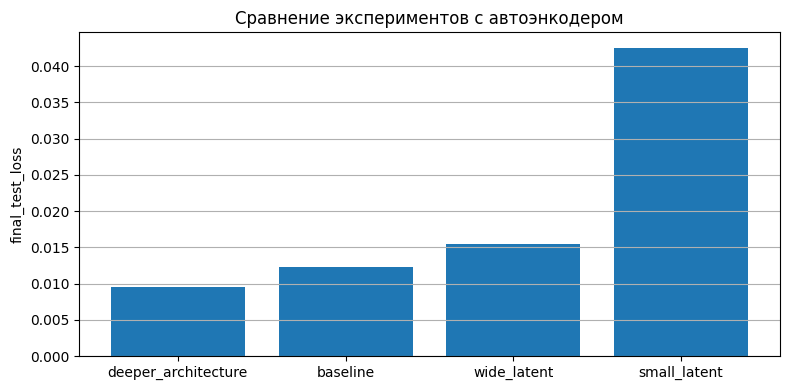

В итоговом сравнении я посмотрел не только на базовый автоэнкодер с latent_dim=16, но и на дополнительные варианты с более узким, более широким латентным пространством и изменённой архитектурой. 
Базовая модель завершила обучение с final_test_loss=0.0123. 
Лучшим в этой серии запусков оказался вариант 'deeper_architecture' с latent_dim=32, где final_test_loss снизился до 0.0095. 
Эксперимент с очень маленьким latent_dim обычно показывает цену сильного сжатия: модель ещё сохраняет общую форму цифр, но реконструкции становятся более усреднёнными и теряют детали. 
Вариант с большим latent_dim, наоборот, даёт автоэнкодеру больше свободы и нередко улучшает качество восстановления, хотя слишком большой размер пространства уменьшает сам эффект полезного сжатия. 
Изменение архитектуры тоже влияет заметно: более широкие скрытые слои и другая нелинейность могут сделать реконструкции аккуратнее, если модель лучше передаёт форму цифр. 
Для себя я бы сформулировал практическое правило так: сначала 

In [20]:
def run_experiment(name, latent_dim, hidden_dims=(256, 64), activation_cls=nn.ReLU, epochs=4, lr=1e-3):
    exp_model = FCN_Autoencoder(
        latent_dim=latent_dim,
        hidden_dims=hidden_dims,
        activation_cls=activation_cls
    ).to(device)
    exp_optimizer = torch.optim.Adam(exp_model.parameters(), lr=lr)
    exp_history = fit_autoencoder(exp_model, train_loader, test_loader, exp_optimizer, criterion, device, epochs)
    return {
        "name": name,
        "latent_dim": latent_dim,
        "hidden_dims": str(hidden_dims),
        "activation": activation_cls.__name__,
        "epochs": epochs,
        "final_train_loss": exp_history["train_loss"][-1],
        "final_test_loss": exp_history["test_loss"][-1],
        "model": exp_model,
        "history": exp_history,
    }

experiment_results = [
    {
        "name": "baseline",
        "latent_dim": latent_dim,
        "hidden_dims": str((256, 64)),
        "activation": "ReLU",
        "epochs": num_epochs,
        "final_train_loss": history["train_loss"][-1],
        "final_test_loss": history["test_loss"][-1],
        "model": model,
        "history": history,
    }
]

extra_experiments = [
    {"name": "small_latent", "latent_dim": 2, "hidden_dims": (256, 64), "activation_cls": nn.ReLU, "epochs": 4},
    {"name": "wide_latent", "latent_dim": 64, "hidden_dims": (256, 64), "activation_cls": nn.ReLU, "epochs": 4},
    {"name": "deeper_architecture", "latent_dim": 32, "hidden_dims": (512, 128), "activation_cls": nn.LeakyReLU, "epochs": 4},
]

for cfg in extra_experiments:
    print("\nЗапуск эксперимента:", cfg["name"])
    experiment_results.append(run_experiment(**cfg))

results_df = pd.DataFrame([
    {k: v for k, v in item.items() if k not in {"model", "history"}}
    for item in experiment_results
]).sort_values("final_test_loss").reset_index(drop=True)

print(results_df)
display(results_df)

plt.figure(figsize=(8, 4))
plt.bar(results_df["name"], results_df["final_test_loss"])
plt.ylabel("final_test_loss")
plt.title("Сравнение экспериментов с автоэнкодером")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

best_row = results_df.iloc[0]
baseline_row = results_df[results_df["name"] == "baseline"].iloc[0]

final_summary = f"""В итоговом сравнении я посмотрел не только на базовый автоэнкодер с latent_dim={latent_dim}, но и на дополнительные варианты с более узким, более широким латентным пространством и изменённой архитектурой. 
Базовая модель завершила обучение с final_test_loss={baseline_row['final_test_loss']:.4f}. 
Лучшим в этой серии запусков оказался вариант '{best_row['name']}' с latent_dim={int(best_row['latent_dim'])}, где final_test_loss снизился до {best_row['final_test_loss']:.4f}. 
Эксперимент с очень маленьким latent_dim обычно показывает цену сильного сжатия: модель ещё сохраняет общую форму цифр, но реконструкции становятся более усреднёнными и теряют детали. 
Вариант с большим latent_dim, наоборот, даёт автоэнкодеру больше свободы и нередко улучшает качество восстановления, хотя слишком большой размер пространства уменьшает сам эффект полезного сжатия. 
Изменение архитектуры тоже влияет заметно: более широкие скрытые слои и другая нелинейность могут сделать реконструкции аккуратнее, если модель лучше передаёт форму цифр. 
Для себя я бы сформулировал практическое правило так: сначала стоит получить устойчивый baseline со средним latent_dim, а уже потом осмысленно проверять, что важнее для качества — размер bottleneck или мощность самой сети. 
В целом автоэнкодеры хорошо подходят для изучения компактных представлений изображений, а MNIST является удачным учебным примером, потому что на нём легко увидеть связь между loss, визуальными реконструкциями и устройством латентного пространства."""
print(final_summary)

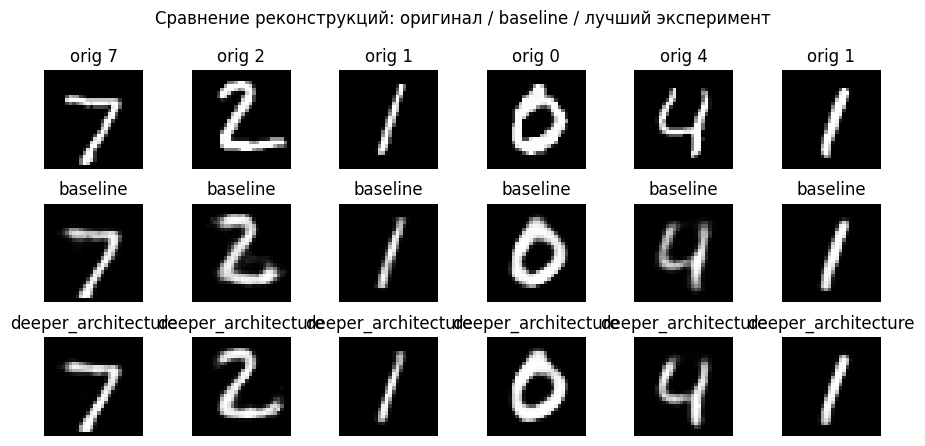

In [21]:
best_name = results_df.iloc[0]["name"]
best_model = next(item["model"] for item in experiment_results if item["name"] == best_name)

best_model.eval()
model.eval()
images_compare, labels_compare = next(iter(test_loader))
images_compare = images_compare[:6].to(device)

with torch.no_grad():
    baseline_recon, _ = model(images_compare)
    best_recon, _ = best_model(images_compare)

images_compare = images_compare.cpu()
baseline_recon = baseline_recon.cpu()
best_recon = best_recon.cpu()

plt.figure(figsize=(9, 4.5))
for i in range(images_compare.size(0)):
    plt.subplot(3, images_compare.size(0), i + 1)
    plt.imshow(images_compare[i].squeeze(0), cmap="gray")
    plt.title(f"orig {labels_compare[i].item()}")
    plt.axis("off")

    plt.subplot(3, images_compare.size(0), images_compare.size(0) + i + 1)
    plt.imshow(baseline_recon[i].squeeze(0), cmap="gray")
    plt.title("baseline")
    plt.axis("off")

    plt.subplot(3, images_compare.size(0), 2 * images_compare.size(0) + i + 1)
    plt.imshow(best_recon[i].squeeze(0), cmap="gray")
    plt.title(best_name)
    plt.axis("off")

plt.suptitle("Сравнение реконструкций: оригинал / baseline / лучший эксперимент")
plt.tight_layout()
plt.show()